In [3]:
!pip install kagglehub tensorflow scikit-learn matplotlib seaborn pillow -q

In [4]:
import os
import warnings
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)

warnings.filterwarnings("ignore")


## Data Loading

In [5]:
# Download dataset from Kaggle
import kagglehub

path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")
print(f" Path to dataset: {path}")

BASE_DIR = pathlib.Path(path) / "PetImages"
print(f" BASE_DIR: {BASE_DIR}")
print(f" Exists: {BASE_DIR.exists()}")

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
 Path to dataset: /kaggle/input/microsoft-catsvsdogs-dataset
 BASE_DIR: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages
 Exists: True


## Data Exploration  

In [7]:
# Check total files and non-JPG files
for cls in ["Cat", "Dog"]:
    cls_dir = BASE_DIR / cls
    all_files = list(cls_dir.iterdir())
    non_jpg = [f.name for f in all_files if f.suffix.lower() != '.jpg']

    print(f"=== {cls} ===")
    print(f"Total files: {len(all_files)}")
    print(f"Non-JPG files: {non_jpg}")
    print()

=== Cat ===
Total files: 12501
Non-JPG files: ['Thumbs.db']

=== Dog ===
Total files: 12501
Non-JPG files: ['Thumbs.db']



In [8]:
# Check total files and non-JPG files
for cls in ["Cat", "Dog"]:
    cls_dir = BASE_DIR / cls
    corrupted = []

    for f in cls_dir.iterdir():
        if f.suffix.lower() != '.jpg':
            corrupted.append(f.name)
            continue
        try:
            img = Image.open(f)
            img.verify()
        except:
            corrupted.append(f.name)

    print(f"=== {cls} ===")
    print(f"Corrupted files: {corrupted}")
    print()

=== Cat ===
Corrupted files: ['Thumbs.db', '666.jpg']

=== Dog ===
Corrupted files: ['11702.jpg', 'Thumbs.db']



## Data Preprocessing

In [9]:
# Skip known corrupted files and collect valid image paths with labels
CORRUPTED = {"Thumbs.db", "666.jpg", "11702.jpg"}

def get_valid_paths(base_dir):
    paths, labels = [], []
    for label, cls in enumerate(["Cat", "Dog"]):
        cls_dir = base_dir / cls
        for f in cls_dir.iterdir():
            if f.name in CORRUPTED:
                continue
            paths.append(str(f))
            labels.append(label)
    return paths, labels

all_paths, all_labels = get_valid_paths(BASE_DIR)
print(f" Valid images: {len(all_paths)}")

 Valid images: 24996


In [10]:
#Split data
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)

print(f"Train: {len(train_paths)}")
print(f"Val:   {len(val_paths)}")
print(f"Test:  {len(test_paths)}")

Train: 17497
Val:   3749
Test:  3750


In [11]:
# Set up data generators to normalize and load images in batches
# Train includes augmentation (flip, rotation), val and test only normalize
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_df = pd.DataFrame({"filepath": train_paths, "label": [str(l) for l in train_labels]})
val_df   = pd.DataFrame({"filepath": val_paths,   "label": [str(l) for l in val_labels]})
test_df  = pd.DataFrame({"filepath": test_paths,  "label": [str(l) for l in test_labels]})

train_gen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=10)
val_gen   = ImageDataGenerator(rescale=1./255)
test_gen  = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)

val_data = val_gen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)

test_data = test_gen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)

Found 17497 validated image filenames belonging to 2 classes.
Found 3749 validated image filenames belonging to 2 classes.
Found 3750 validated image filenames belonging to 2 classes.


## Model

In [12]:
# CNN architecture: 4 conv blocks + sigmoid output
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,778,049 (33.49 MB)

 Trainable params: 8,778,049 (33.49 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model.keras", save_best_only=True, verbose=1)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.5247 - loss: 0.7030
Epoch 1: val_loss improved from inf to 0.65513, saving model to best_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 138s 241ms/step - accuracy: 0.5247 - loss: 0.7030 - val_accuracy: 0.5906 - val_loss: 0.6551
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.6776 - loss: 0.6059
Epoch 2: val_loss improved from 0.65513 to 0.51353, saving model to best_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 128s 234ms/step - accuracy: 0.6776 - loss: 0.6059 - val_accuracy: 0.7474 - val_loss: 0.5135
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7386 - loss: 0.5272
Epoch 3: val_loss improved from 0.51353 to 0.46555, saving model to best_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 127s 232ms/step - accuracy: 0.7386 - loss: 0.5272 - val_accuracy: 0.7815 - val_loss: 0.4656
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.7907 - loss: 0.4451
Epoch 4: val_loss improved from 0.

## Evaluation

In [14]:
# Evaluate on test set (unseen data)
y_pred = (model.predict(test_data) > 0.5).astype(int).flatten()
y_true = test_data.labels

print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["Cat", "Dog"]))

118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step
Accuracy:  0.8917
Precision: 0.8951
Recall:    0.8875
F1-Score:  0.8913

              precision    recall  f1-score   support

         Cat       0.89      0.90      0.89      1875
         Dog       0.90      0.89      0.89      1875

    accuracy                           0.89      3750
   macro avg       0.89      0.89      0.89      3750
weighted avg       0.89      0.89      0.89      3750



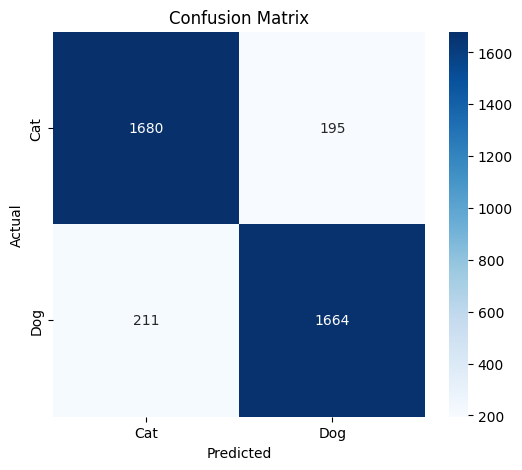

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

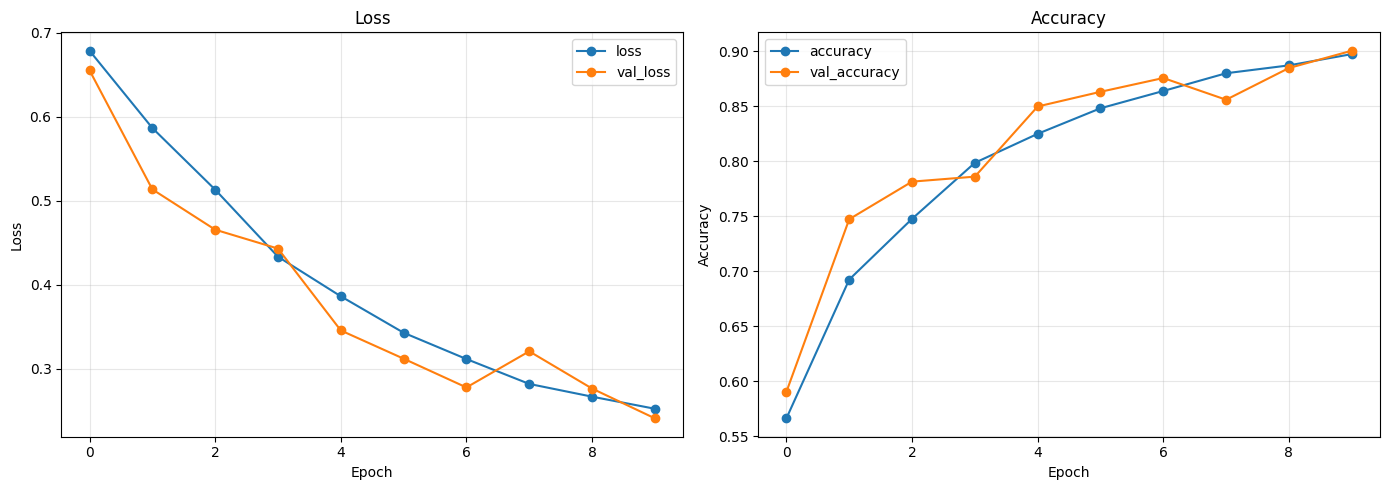

In [17]:
#Loss & Accuracy Plots
history_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

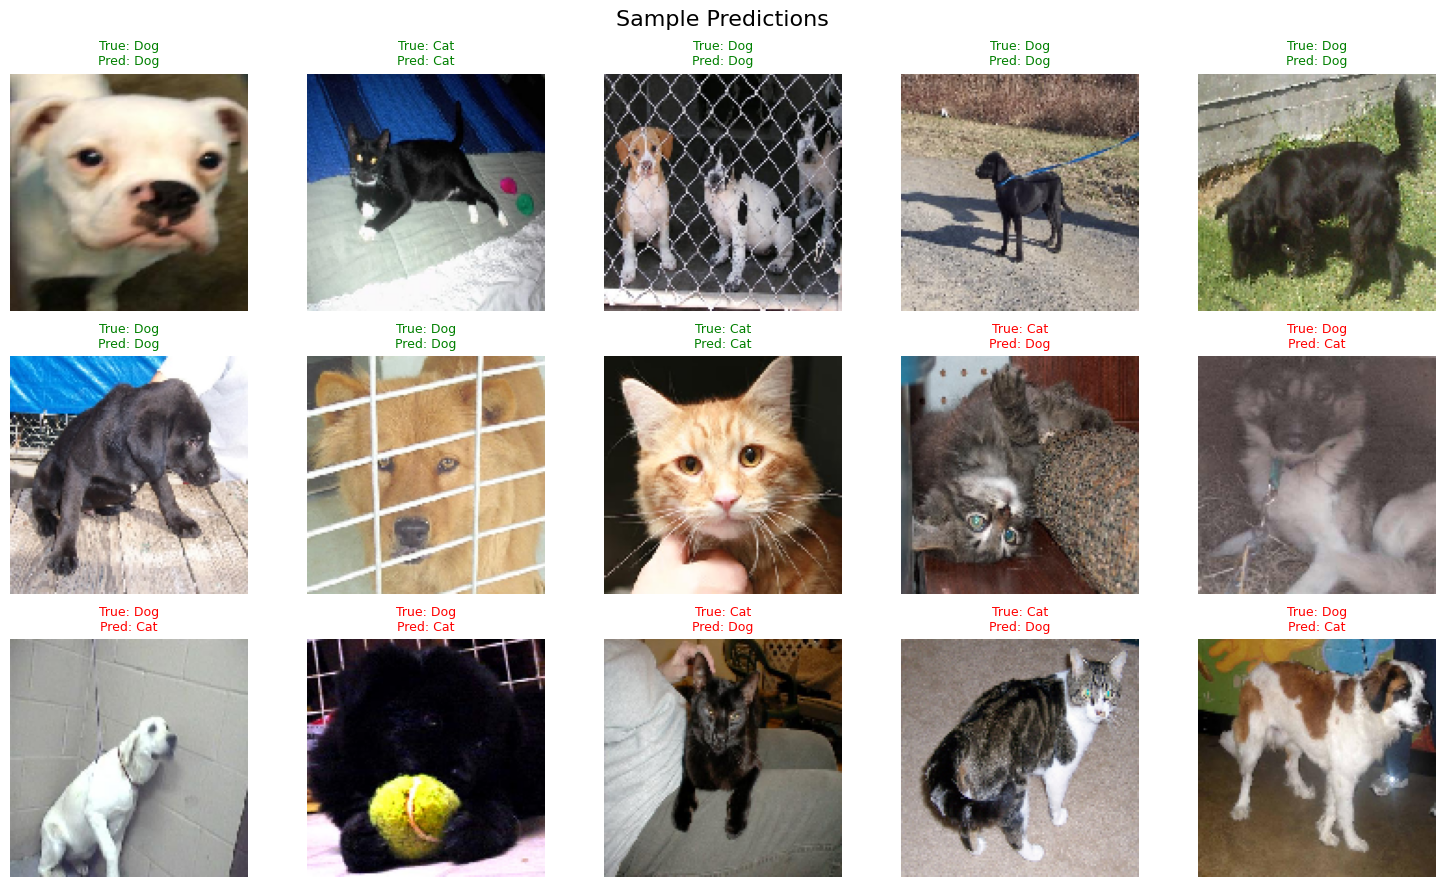

In [23]:
# Display correct (green) and wrong (red) predictions from test set
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Predictions', fontsize=16)

label_names = {0: 'Cat', 1: 'Dog'}


correct_indices = np.where(y_pred == y_true)[0][:8]
wrong_indices   = np.where(y_pred != y_true)[0][:7]
sample_indices  = np.concatenate([correct_indices, wrong_indices])

for i, idx in enumerate(sample_indices):
    img = load_img(test_paths[idx], target_size=IMG_SIZE)
    is_correct = y_pred[idx] == y_true[idx]
    color = 'green' if is_correct else 'red'

    axes[i//5, i%5].imshow(img)
    axes[i//5, i%5].set_title(
        f"True: {label_names[y_true[idx]]}\nPred: {label_names[y_pred[idx]]}",
        fontsize=9, color=color
    )
    axes[i//5, i%5].axis('off')

plt.tight_layout()
plt.show()

##Findings

Accuracy: 0.8917
Loss: 0.2411

Observations:
- The model achieves 89.17% accuracy with balanced performance on both classes
- The model still misclassifies some images, particularly black cats and long-haired dogs which share visual features